# Notebook 1: DEM Preparation and Alignment

Downloads SRTM, loads glacier shapefiles and additional DEMs, reprojects everything to a common CRS and grid, and saves aligned DEMs for Notebook 2.

This workflow is fully open-source (rasterio, rioxarray, GDAL, pyproj). No ArcPy or commercial software required.

## DEM inventory

| DEM | Date | Source | Resolution |
|-----|------|--------|------------|
| IGM_1954 | 1954 | Chilean Military Geographic Institute (IGM) aerial survey | 30m |
| SRTM_2000 | Feb 2000 | NASA Shuttle Radar Topography Mission | 30m (~1 arcsec) |
| ASTER_2004–2018 | 2004–2018 | ASTER stereo (Hugonnet et al. 2021, bias-corrected) | 30m |
| CerroBlanco_2024 | Mar 2024 | UAV survey (DJI Phantom 4 RTK) | ~0.1m native |
| LasTermas_2024 | Mar 2024 | UAV survey (DJI Phantom 4 RTK) | ~0.1m native |
| Pleiades_2025 | Apr 2025 | Pléiades stereo (DGA/Transparency Act, built by J. Berkhoff) | 1m native |

**INPUTS:**
- Raw DEM files in `example_data_Nevados/Nevados_DEMs/`
- Glacier shapefiles (DGA 2000 and 2019)
- SRTM tiles downloaded via earthaccess

**OUTPUTS:**
- `aligned_dems/<name>_aligned.tif` — all DEMs on the same CRS + grid (EPSG:32719, 30m)

In [14]:
# ==============================================================================
# Imports
# ==============================================================================
import os
import zipfile
import shutil
from pathlib import Path
from datetime import datetime
from io import BytesIO

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import requests
from PIL import Image
import paramiko

import rasterio
from rasterio.merge import merge as rio_merge
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.transform import from_origin
from rasterio.crs import CRS as RasterioCRS
from rasterio.mask import mask as rio_mask
from rasterio.windows import from_bounds
from shapely.geometry import box

import rioxarray as rxr
import earthaccess

print('All imports successful.')

All imports successful.


In [15]:
# ==============================================================================
# User variables — update paths as needed
# ==============================================================================

# Target CRS: WGS84 / UTM Zone 19S (appropriate for Nevados de Chillán)
TARGET_CRS = 'EPSG:32719'
EXACT_RES  = 30.0  # exactly 30m square pixels

# Bounding box for SRTM download: (west, south, east, north)
BOUNDING_BOX = (-71.4, -36.8, -71.2, -36.6)

# Folder for raw SRTM tiles
SRTM_RAW_DIR = './srtm_data'

# Folder containing raw DEMs
DEM_FOLDER = 'example_data_Nevados/Nevados_DEMs'

# DEM filenames (must be in DEM_FOLDER)
# SRTM_2000 is built from downloaded tiles in Step 1 and added automatically.
DEM_FILES = {
    'IGM_1954':         'IGM_1954.tif',
    'CerroBlanco_2024': 'CerroBlanco_2024.tif',
    'LasTermas_2024':   'LasTermas_2024.tif',
    'Pleiades_2025':    'Pleiades_2025.tif',
    'ASTER_2004':       'ASTER_2004.tif',
    'ASTER_2004b':      'ASTER_2004b.tif',
    'ASTER_2005':       'ASTER_2005.tif',
    'ASTER_2006':       'ASTER_2006.tif',
    'ASTER_2007':       'ASTER_2007.tif',
    'ASTER_2008':       'ASTER_2008.tif',
    'ASTER_2014':       'ASTER_2014.tif',
    'ASTER_2015':       'ASTER_2015.tif',
    'ASTER_2018':       'ASTER_2018.tif',
    # SRTM_2000 added automatically below
}

# Glacier shapefile paths
GLACIER_1975_PATH = '/Users/milliespencer/Desktop/70_Years_MB_Nevados/NdC_1975_glacier_poly/Shp/Nevados_Chillan_1975.shp'
GLACIER_2000_PATH = 'example_data_Nevados/Nevados_glacier_shapefiles/Nevados_shapefile_DGA2000/Nevados_polygons_DGA2000.shp'
GLACIER_2019_PATH = 'example_data_Nevados/Nevados_glacier_shapefiles/Nevados_shapefile_DGA2019/Nevados_polygons_DGA2019.shp'

# Output folder for aligned DEMs
OUTPUT_FOLDER = 'aligned_dems'
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

print('User variables set.')

User variables set.


## ASTER DEM browse image preview

The ASTER DEMs (2004–2018) were selected from 122 granules intersecting the study area on Hugonnet's SFTP server. We filtered to February–March acquisitions (peak ablation season, minimal snow cover) and assessed cloud cover visually using NASA Earthdata browse images. Scenes with heavy snow or cloud cover over the complex were excluded. The final selection was further filtered using Hugonnet's bias-correction quality metrics (NMAD after co-registration).

Run the cell below to regenerate the browse image preview. Requires an active NASA Earthdata login.

Found 22 browse images


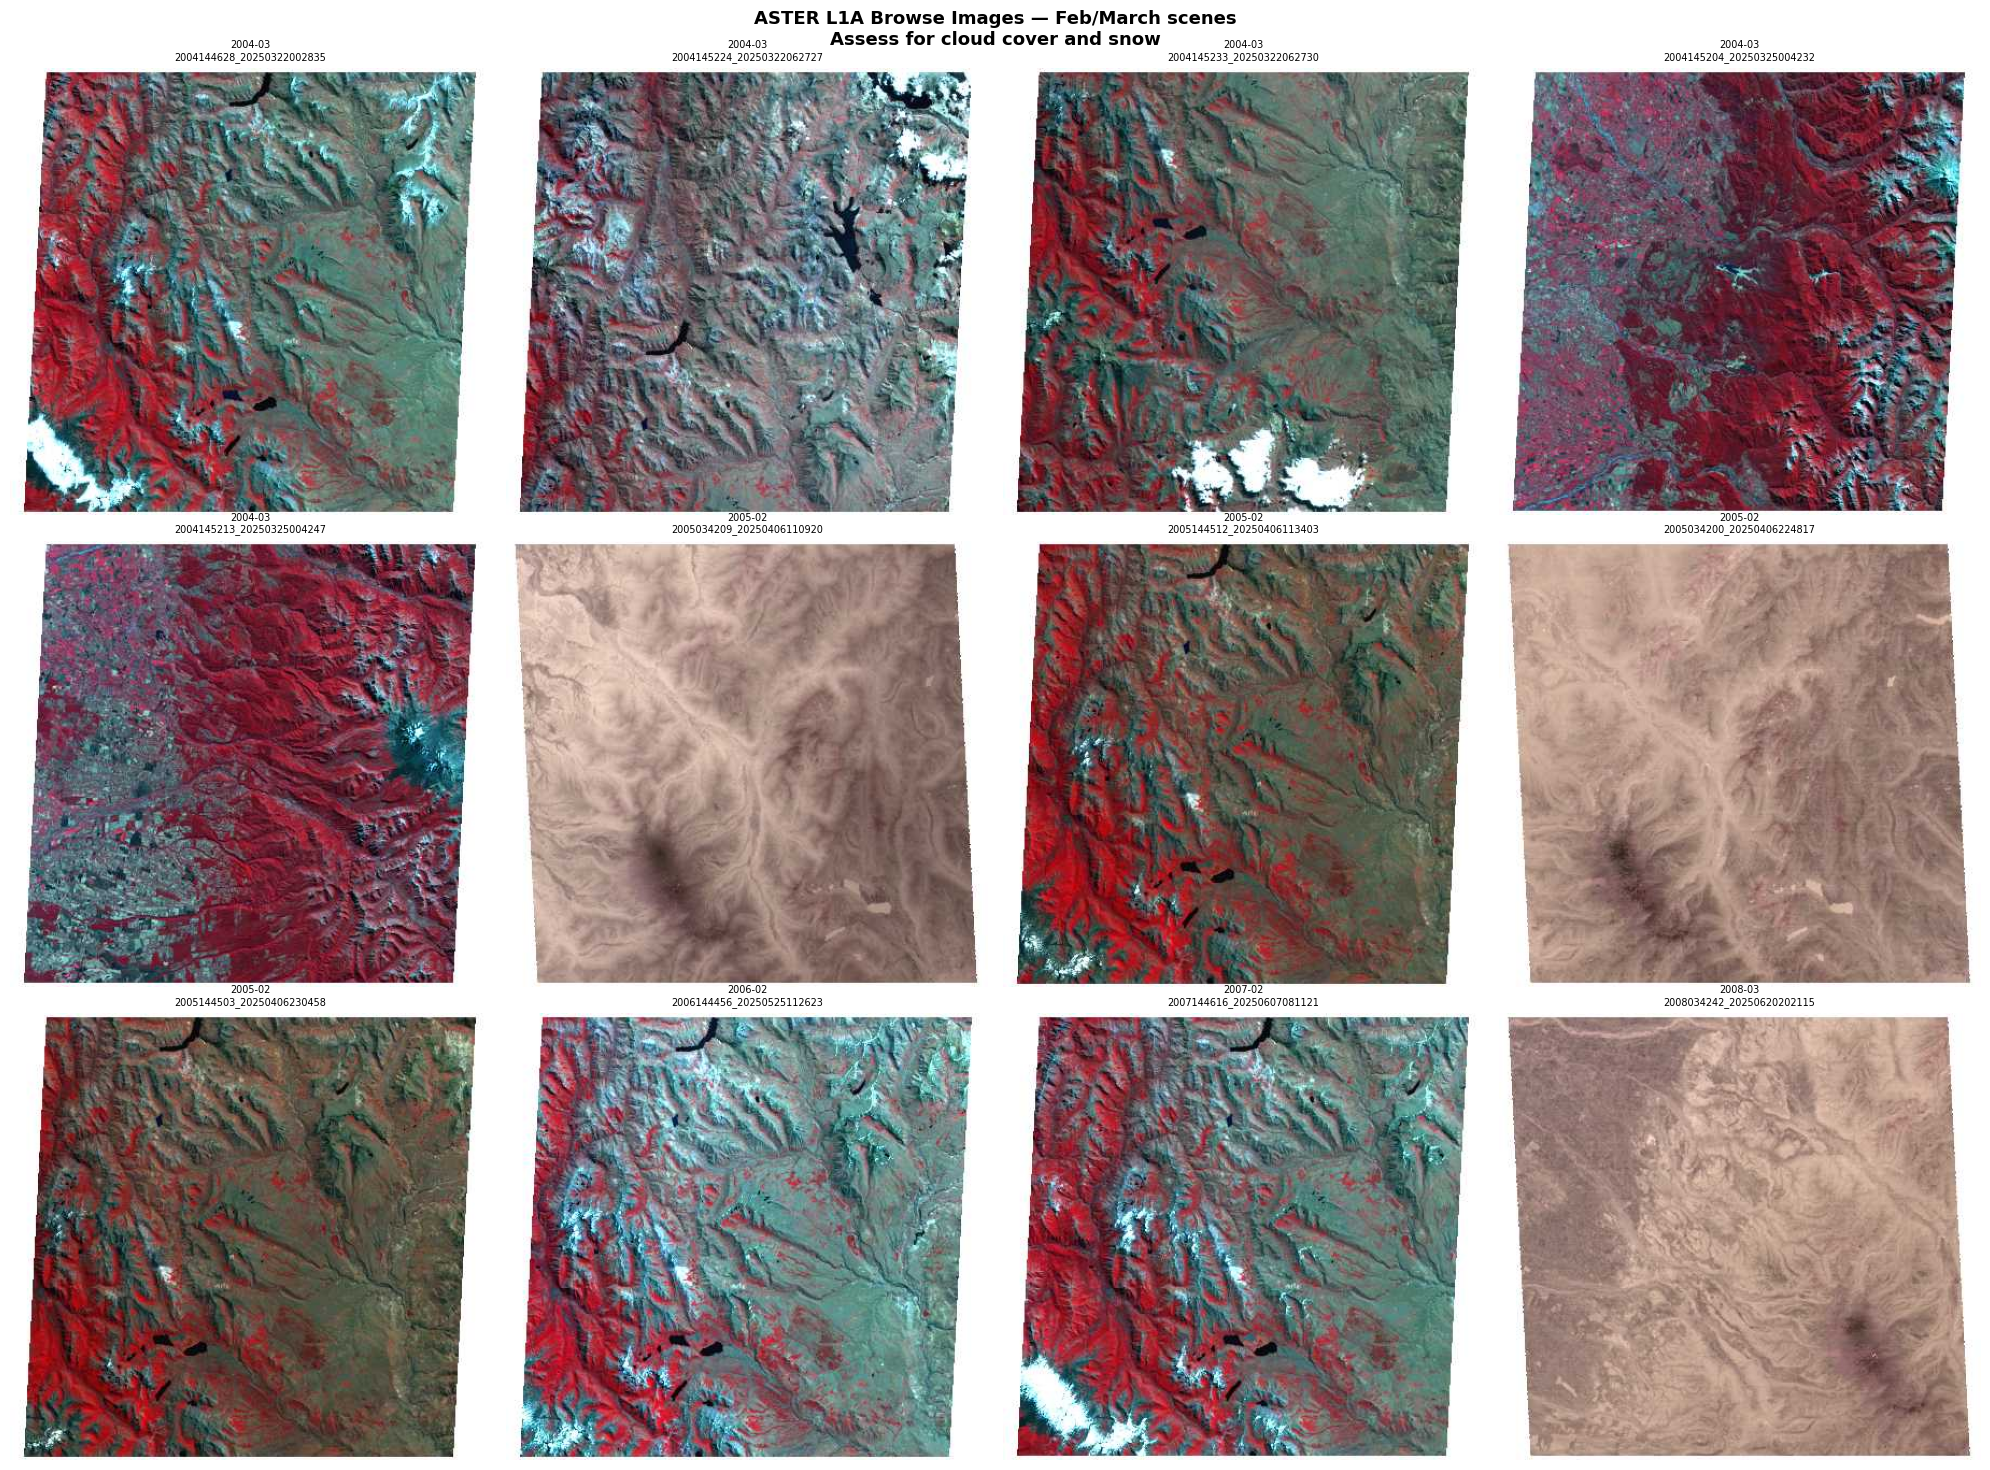

In [16]:
# ==============================================================================
# ASTER browse image preview (Feb-March scenes)
# Fetches small JPEG thumbnails from NASA Earthdata for visual QC.
# Requires NASA Earthdata login (run earthaccess.login(persist=True) once).
# ==============================================================================

earthaccess.login(persist=True)

bounding_box = (-71.4, -36.9, -71.2, -36.6)
date_ranges  = [
    ('2004-03-01', '2004-03-31'), ('2005-02-01', '2005-02-28'),
    ('2006-02-01', '2006-02-28'), ('2007-02-01', '2007-02-28'),
    ('2008-03-01', '2008-03-31'), ('2014-02-01', '2014-02-28'),
    ('2015-02-01', '2015-02-28'), ('2018-03-01', '2018-03-31'),
]

browse_scenes = []
for t_start, t_end in date_ranges:
    results = earthaccess.search_data(
        short_name='AST_L1A', bounding_box=bounding_box, temporal=(t_start, t_end)
    )
    for r in results:
        name = r['meta']['native-id']
        for url in r.get('umm', {}).get('RelatedUrls', []):
            if url.get('Type') == 'GET RELATED VISUALIZATION' and \
               url.get('URL', '').startswith('https://'):
                browse_scenes.append({'name': name, 'date': t_start[:7], 'url': url['URL']})
                break

print(f'Found {len(browse_scenes)} browse images')

# Display grid
n    = min(len(browse_scenes), 12)
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()

for i, scene in enumerate(browse_scenes[:n]):
    try:
        resp = requests.get(scene['url'], timeout=30)
        img  = Image.open(BytesIO(resp.content))
        axes[i].imshow(img)
        axes[i].set_title(f"{scene['date']}\n{scene['name'][-25:]}", fontsize=7)
    except Exception as e:
        axes[i].text(0.5, 0.5, f"{scene['date']}\nError", ha='center', va='center', fontsize=7)
    axes[i].axis('off')

for j in range(n, len(axes)):
    axes[j].axis('off')

plt.suptitle('ASTER L1A Browse Images — Feb/March scenes\nAssess for cloud cover and snow',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('aster_browse_preview.png', dpi=150, bbox_inches='tight')
plt.show()

## ASTER DEM quality assessment

Hugonnet et al. provide bias-correction log files for each DEM. We parse these to extract NMAD before and after co-registration, which serves as our primary quality metric. Lower post-correction NMAD = better DEM quality.

In [17]:
# ==============================================================================
# ASTER DEM quality assessment from Hugonnet bias-correction logs
# ==============================================================================
import re

qc_dir = Path('/Users/milliespencer/Desktop/70_Years_MB_Nevados/Hugonnet/qc_files')

results_qc = []
for granule_dir in sorted(qc_dir.iterdir()):
    if not granule_dir.is_dir():
        continue
    log_files = [f for f in granule_dir.iterdir()
                 if f.suffix == '.log' and 'error' not in f.name]
    if not log_files:
        continue
    log_text  = log_files[0].read_text(errors='replace')
    iter_lines = []
    for line in log_text.strip().split('\n'):
        parts = line.strip().split()
        if len(parts) == 3:
            try:
                iter_lines.append([float(p) for p in parts])
            except:
                pass
    if iter_lines:
        median_before, nmad_before = iter_lines[0][0],  iter_lines[0][2]
        median_after,  nmad_after  = iter_lines[-1][0], iter_lines[-1][2]
    else:
        median_before = nmad_before = median_after = nmad_after = None
    orig  = re.search(r'Original Sample size\s*:\s*(\d+)', log_text)
    final = re.search(r'Final Sample size\s*:\s*(\d+)',    log_text)
    results_qc.append({
        'granule':       granule_dir.name,
        'median_before': round(median_before, 2) if median_before else None,
        'nmad_before':   round(nmad_before, 2)   if nmad_before   else None,
        'median_after':  round(median_after, 2)  if median_after  else None,
        'nmad_after':    round(nmad_after, 2)    if nmad_after    else None,
        'n_orig':        int(orig.group(1))       if orig          else None,
        'n_final':       int(final.group(1))      if final         else None,
    })

df_qc = pd.DataFrame(results_qc).sort_values('nmad_after')
print('ASTER DEM quality metrics (sorted by NMAD after bias correction):')
print(df_qc.to_string(index=False))

ASTER DEM quality metrics (sorted by NMAD after bias correction):
                  granule  median_before  nmad_before  median_after  nmad_after  n_orig  n_final
AST_L1A_00303102004145215          19.54        12.21         -0.39        0.03 7030300  6998489
AST_L1A_00302242007144558          -0.32        27.62          0.44        0.07 7121872  7091270
AST_L1A_00302182005144503          -4.51        16.42         -0.51        0.09 7735764  7710144
AST_L1A_00303302008144525           9.32         8.53         -0.53        0.14 7152798  7127267
AST_L1A_00303012018145201          25.55        39.35          0.58        0.17 8036832  7995123
AST_L1A_00302212006144456          -7.12        21.67          0.42        0.22 6765590  6735573
AST_L1A_00302112014144558          -8.69        21.34         -0.68        0.23 7386970  7363926
AST_L1A_00302112014144540         -17.60        24.90          0.69        0.29 7118313  7093980
AST_L1A_00302212015145214          20.03        34.22        

In [18]:
# ==============================================================================
# Step 1: Download and prepare SRTM DEM
# ==============================================================================
print('=' * 60)
print('Step 1: SRTM download and preparation')
print('=' * 60)

os.makedirs(SRTM_RAW_DIR, exist_ok=True)

if not any(f.endswith(('.hgt', '.tif')) for f in os.listdir(SRTM_RAW_DIR)):
    print('Logging in to EarthAccess...')
    earthaccess.login()
    results = earthaccess.search_data(short_name='SRTMGL1', bounding_box=BOUNDING_BOX)
    print(f'Found {len(results)} SRTM granule(s).')
    for granule in results:
        earthaccess.download(granule, SRTM_RAW_DIR)
else:
    print(f'SRTM files already present in {SRTM_RAW_DIR}, skipping download.')

# Unzip
for fname in os.listdir(SRTM_RAW_DIR):
    if fname.endswith('.zip'):
        zip_path = os.path.join(SRTM_RAW_DIR, fname)
        extracted = fname.replace('.zip', '')
        if not os.path.exists(os.path.join(SRTM_RAW_DIR, extracted)):
            with zipfile.ZipFile(zip_path, 'r') as zf:
                zf.extractall(SRTM_RAW_DIR)
            print(f'  Unzipped: {fname}')

# Collect tiles
srtm_tiles = [os.path.join(SRTM_RAW_DIR, f)
               for f in os.listdir(SRTM_RAW_DIR) if f.endswith('.hgt')]
print(f'Found {len(srtm_tiles)} SRTM tile(s): {[os.path.basename(t) for t in srtm_tiles]}')

# Merge and clip
srtm_out_path = os.path.join(DEM_FOLDER, 'SRTM_2000.tif')
if not os.path.exists(srtm_out_path):
    print('Merging SRTM tiles...')
    tile_datasets = [rasterio.open(t) for t in srtm_tiles]
    merged, merged_transform = rio_merge(tile_datasets)
    merged_meta = tile_datasets[0].meta.copy()
    merged_meta.update({'driver': 'GTiff', 'height': merged.shape[1],
                        'width': merged.shape[2], 'transform': merged_transform,
                        'crs': tile_datasets[0].crs})
    for ds in tile_datasets:
        ds.close()
    with rasterio.MemoryFile() as memfile:
        with memfile.open(**merged_meta) as mem:
            mem.write(merged)
            west, south, east, north = BOUNDING_BOX
            window       = from_bounds(west, south, east, north, transform=merged_transform)
            clipped      = mem.read(window=window)
            clip_transform = mem.window_transform(window)
    clip_meta = merged_meta.copy()
    clip_meta.update({'height': clipped.shape[1], 'width': clipped.shape[2],
                      'transform': clip_transform})
    os.makedirs(DEM_FOLDER, exist_ok=True)
    with rasterio.open(srtm_out_path, 'w', **clip_meta) as dst:
        dst.write(clipped)
    print(f'  SRTM merged and clipped → {srtm_out_path}')
else:
    print(f'  SRTM_2000.tif already exists, skipping merge.')

DEM_FILES['SRTM_2000'] = 'SRTM_2000.tif'

Step 1: SRTM download and preparation
SRTM files already present in ./srtm_data, skipping download.
  Unzipped: N58W134.SRTMGL1.hgt.zip
  Unzipped: N59W134.SRTMGL1.hgt.zip
  Unzipped: N58W135.SRTMGL1.hgt.zip
  Unzipped: N59W135.SRTMGL1.hgt.zip
  Unzipped: S37W072.SRTMGL1.hgt.zip
Found 5 SRTM tile(s): ['N58W134.hgt', 'N58W135.hgt', 'N59W134.hgt', 'N59W135.hgt', 'S37W072.hgt']
  SRTM_2000.tif already exists, skipping merge.


In [19]:
# ==============================================================================
# Step 2: Load glacier shapefiles
# ==============================================================================
print('\n' + '=' * 60)
print('Step 2: Load glacier shapefiles')
print('=' * 60)

glacier_1975_gdf = gpd.read_file(GLACIER_1975_PATH)
glacier_2000_gdf = gpd.read_file(GLACIER_2000_PATH)
glacier_2019_gdf = gpd.read_file(GLACIER_2019_PATH)

print(f'NdC 1975:  {len(glacier_1975_gdf)} polygons, CRS: {glacier_1975_gdf.crs}')
print(f'DGA 2000:  {len(glacier_2000_gdf)} polygons, CRS: {glacier_2000_gdf.crs}')
print(f'DGA 2019:  {len(glacier_2019_gdf)} polygons, CRS: {glacier_2019_gdf.crs}')
print(f'1975 area: {glacier_1975_gdf.to_crs("EPSG:32719").area.sum()/1e6:.2f} km²')
print(f'2000 area: {glacier_2000_gdf.to_crs("EPSG:32719").area.sum()/1e6:.2f} km²')
print(f'2019 area: {glacier_2019_gdf.to_crs("EPSG:32719").area.sum()/1e6:.2f} km²')


Step 2: Load glacier shapefiles
NdC 1975:  7 polygons, CRS: EPSG:32719
DGA 2000:  28 polygons, CRS: EPSG:32719
DGA 2019:  993 polygons, CRS: EPSG:32719
1975 area: 16.02 km²
2000 area: 2.91 km²
2019 area: 1.90 km²


In [20]:
# ==============================================================================
# Step 3: Reproject and align all DEMs to SRTM reference grid
# ==============================================================================
# All DEMs are:
#   1. Reprojected to TARGET_CRS (EPSG:32719, UTM 19S)
#   2. Resampled to match the SRTM_2000 pixel grid using bilinear interpolation
#
# The reference DEM (SRTM) is reprojected first with EXACTLY 30m square pixels
# by snapping to a clean grid origin. All other DEMs then use reproject_match()
# which inherits the clean 30m transform exactly, avoiding floating point drift
# (e.g. 30.00000000022571 x 30.00000000022562) that breaks xDEM terrain tools.
#
# Elevation artifact cleaning: values outside 0-7000m are masked before
# resampling. This catches ASTER stereo artifacts (~-500m) and prevents
# them from contaminating 30m resampled pixels.

print('\n' + '=' * 60)
print('Step 3: Reproject and align DEMs')
print('=' * 60)

dst_crs = RasterioCRS.from_epsg(32719)

# --- Build reference DEM with exactly 30m square pixels ---
ref_path = os.path.join(DEM_FOLDER, 'SRTM_2000.tif')
print(f'\nReprojecting reference DEM: {ref_path}')

with rasterio.open(ref_path) as src:
    transform, width, height = calculate_default_transform(
        src.crs, dst_crs, src.width, src.height, *src.bounds)
    x_origin = round(transform.c / EXACT_RES) * EXACT_RES
    y_origin = round(transform.f / EXACT_RES) * EXACT_RES
    clean_transform = from_origin(x_origin, y_origin, EXACT_RES, EXACT_RES)
    clean_width  = int(round((transform.c + transform.a * width  - x_origin) / EXACT_RES)) + 1
    clean_height = int(round((y_origin - (transform.f + transform.e * height)) / EXACT_RES)) + 1
    profile = src.profile.copy()
    profile.update(crs=dst_crs, transform=clean_transform, width=clean_width,
                   height=clean_height, dtype='float32', nodata=np.nan, count=1)
    ref_data = np.empty((1, clean_height, clean_width), dtype=np.float32)
    reproject(source=rasterio.band(src, 1), destination=ref_data,
              src_transform=src.transform, src_crs=src.crs,
              dst_transform=clean_transform, dst_crs=dst_crs,
              resampling=Resampling.bilinear)

ref_aligned_path = os.path.join(OUTPUT_FOLDER, 'SRTM_2000_aligned.tif')
with rasterio.open(ref_aligned_path, 'w', **profile) as dst:
    dst.write(ref_data)

reference = rxr.open_rasterio(ref_aligned_path, masked=True).squeeze()
print(f'  CRS: {reference.rio.crs}  |  Resolution: {[abs(r) for r in reference.rio.resolution()]} m')
print(f'  Shape: {reference.shape}  |  Saved: {ref_aligned_path}')

# --- Reproject and align all other DEMs ---
for dem_name, dem_filename in DEM_FILES.items():
    if dem_name == 'SRTM_2000':
        continue
    dem_path = os.path.join(DEM_FOLDER, dem_filename)
    out_path = os.path.join(OUTPUT_FOLDER, f'{dem_name}_aligned.tif')
    if os.path.exists(out_path):
        print(f'\n  {dem_name}: already aligned, skipping.')
        continue
    print(f'\n  Processing: {dem_name}')
    dem = rxr.open_rasterio(dem_path, masked=True).squeeze()
    # Mask elevation artifacts before resampling
    dem = dem.where((dem > 0) & (dem < 7000))
    print(f'    Input CRS: {dem.rio.crs}, res: {[abs(r) for r in dem.rio.resolution()]}')
    if dem_name == 'IGM_1954' and dem.rio.crs is None:
        print('    WARNING: IGM_1954 has no CRS. Assigning PSAD56 UTM 19S (EPSG:24879).')
        dem = dem.rio.write_crs('EPSG:24879')
    dem_aligned = dem.rio.reproject(TARGET_CRS).rio.reproject_match(
        reference, resampling=Resampling.bilinear)
    print(f'    Output: {dem_aligned.rio.crs}, {[abs(r) for r in dem_aligned.rio.resolution()]} m')
    dem_aligned.rio.to_raster(out_path)
    print(f'    Saved: {out_path}')


Step 3: Reproject and align DEMs

Reprojecting reference DEM: example_data_Nevados/Nevados_DEMs/SRTM_2000.tif
  CRS: EPSG:32719  |  Resolution: [30.0, 30.0] m
  Shape: (3779, 3084)  |  Saved: aligned_dems/SRTM_2000_aligned.tif

  IGM_1954: already aligned, skipping.

  Processing: CerroBlanco_2024
    Input CRS: EPSG:4326, res: [8.761960000002116e-07, 7.042859999999532e-07]
    Output: EPSG:32719, [30.0, 30.0] m
    Saved: aligned_dems/CerroBlanco_2024_aligned.tif

  LasTermas_2024: already aligned, skipping.

  Pleiades_2025: already aligned, skipping.

  ASTER_2004: already aligned, skipping.

  ASTER_2004b: already aligned, skipping.

  ASTER_2005: already aligned, skipping.

  ASTER_2006: already aligned, skipping.

  ASTER_2007: already aligned, skipping.

  ASTER_2008: already aligned, skipping.

  ASTER_2014: already aligned, skipping.

  ASTER_2015: already aligned, skipping.

  ASTER_2018: already aligned, skipping.


In [21]:
# ==============================================================================
# Step 4: Geoid correction — convert ellipsoidal to orthometric heights
# ==============================================================================
# CerroBlanco, LasTermas, Pleiades are in WGS84 ellipsoidal heights (DJI RTK,
# Metashape default; Pleiades confirmed by Jorge Berkhoff).
# SRTM and IGM are already orthometric — no correction needed.
# ASTER DEMs are hashed out of current workflow pending datum confirmation.
#
# Conversion: h_orthometric = h_ellipsoidal - N
# where N is the EGM96 geoid undulation (~22-24m at 37°S, 71°W)
#
# Output: aligned_dems_geoid/ — corrected DEMs ready for co-registration
#         aligned_dems/ — preserved unchanged as clean intermediate
# ==============================================================================
from pyproj import Transformer
import numpy as np
import rasterio
import shutil
import os

GEOID_OUTPUT_FOLDER = 'aligned_dems_geoid'
os.makedirs(GEOID_OUTPUT_FOLDER, exist_ok=True)

# Only these three need correction — confirmed ellipsoidal
ELLIPSOIDAL_DEMS = [
    'CerroBlanco_2024',
    'LasTermas_2024',
    'Pleiades_2025',
]

# These are already orthometric — copy directly
ORTHOMETRIC_DEMS = [
    'SRTM_2000',
    'IGM_1954',
]

t_geoid  = Transformer.from_crs("EPSG:4326+5773", "EPSG:4979", always_xy=True)
t_to_geo = Transformer.from_crs("EPSG:32719", "EPSG:4326", always_xy=True)

def get_geoid_undulation_grid(src):
    height, width = src.shape
    bounds, transform = src.bounds, src.transform
    cols = np.arange(width)
    rows = np.arange(height)
    col_grid, row_grid = np.meshgrid(cols, rows)
    x_grid = bounds.left + (col_grid + 0.5) * transform.a
    y_grid = bounds.top  + (row_grid + 0.5) * transform.e
    lon_grid, lat_grid = t_to_geo.transform(x_grid, y_grid)
    _, _, z_ellip = t_geoid.transform(lon_grid, lat_grid, np.zeros_like(lon_grid))
    return z_ellip

print('Applying geoid correction (ellipsoidal → orthometric)...')
for dem_name in ELLIPSOIDAL_DEMS:
    src_path = os.path.join(OUTPUT_FOLDER, f'{dem_name}_aligned.tif')
    dst_path = os.path.join(GEOID_OUTPUT_FOLDER, f'{dem_name}_aligned.tif')
    if os.path.exists(dst_path):
        print(f'  {dem_name}: already corrected, skipping.')
        continue
    print(f'  {dem_name}...')
    with rasterio.open(src_path) as src:
        data    = src.read(1).astype(float)
        profile = src.profile.copy()
        if src.nodata is not None:
            data[data == src.nodata] = np.nan
        data[data < 0]    = np.nan
        data[data > 7000] = np.nan
        N = get_geoid_undulation_grid(src)
    print(f'    N range: {N.min():.2f}–{N.max():.2f}m (mean: {N.mean():.2f}m)')
    corrected = data - N
    corrected[~np.isfinite(data)] = np.nan
    profile.update(dtype='float32', nodata=np.nan)
    with rasterio.open(dst_path, 'w', **profile) as dst:
        dst.write(corrected.astype('float32'), 1)
    print(f'    Saved: {dst_path}')

print('\nCopying orthometric DEMs (no correction needed)...')
for dem_name in ORTHOMETRIC_DEMS:
    src_path = os.path.join(OUTPUT_FOLDER, f'{dem_name}_aligned.tif')
    dst_path = os.path.join(GEOID_OUTPUT_FOLDER, f'{dem_name}_aligned.tif')
    if os.path.exists(dst_path):
        print(f'  {dem_name}: already exists, skipping.')
        continue
    shutil.copy(src_path, dst_path)
    print(f'  {dem_name}: copied.')

print(f'\nStep 4 complete. Geoid-corrected DEMs in: {GEOID_OUTPUT_FOLDER}/')
print('aligned_dems/ preserved unchanged.')

Applying geoid correction (ellipsoidal → orthometric)...
  CerroBlanco_2024...
    N range: 20.70–25.30m (mean: 22.63m)
    Saved: aligned_dems_geoid/CerroBlanco_2024_aligned.tif
  LasTermas_2024: already corrected, skipping.
  Pleiades_2025: already corrected, skipping.

Copying orthometric DEMs (no correction needed)...
  SRTM_2000: already exists, skipping.
  IGM_1954: already exists, skipping.

Step 4 complete. Geoid-corrected DEMs in: aligned_dems_geoid/
aligned_dems/ preserved unchanged.


In [22]:
# ==============================================================================
# Step 5: Alignment verification
# ==============================================================================
print('\n' + '=' * 60)
print('Step 4: Alignment verification')
print('=' * 60)
print(f"{'DEM':<25} {'CRS':<15} {'X res (m)':<12} {'Y res (m)':<12} {'Shape'}")

for dem_name in DEM_FILES:
    aligned_path = os.path.join(OUTPUT_FOLDER, f'{dem_name}_aligned.tif')
    if not os.path.exists(aligned_path):
        print(f'  {dem_name:<23} NOT FOUND')
        continue
    with rasterio.open(aligned_path) as src:
        xres  = abs(src.transform.a)
        yres  = abs(src.transform.e)
        shape = (src.height, src.width)
        crs_s = str(src.crs).split(':')[-1] if src.crs else 'None'
    print(f'  {dem_name:<23} EPSG:{crs_s:<10} {xres:<12.2f} {yres:<12.2f} {shape}')


Step 4: Alignment verification
DEM                       CRS             X res (m)    Y res (m)    Shape
  IGM_1954                EPSG:32719      30.00        30.00        (3779, 3084)
  CerroBlanco_2024        EPSG:32719      30.00        30.00        (3779, 3084)
  LasTermas_2024          EPSG:32719      30.00        30.00        (3779, 3084)
  Pleiades_2025           EPSG:32719      30.00        30.00        (3779, 3084)
  ASTER_2004              EPSG:32719      30.00        30.00        (3779, 3084)
  ASTER_2004b             EPSG:32719      30.00        30.00        (3779, 3084)
  ASTER_2005              EPSG:32719      30.00        30.00        (3779, 3084)
  ASTER_2006              EPSG:32719      30.00        30.00        (3779, 3084)
  ASTER_2007              EPSG:32719      30.00        30.00        (3779, 3084)
  ASTER_2008              EPSG:32719      30.00        30.00        (3779, 3084)
  ASTER_2014              EPSG:32719      30.00        30.00        (3779, 3084)
  A


Generating overview plots...
Found 14 aligned DEMs.


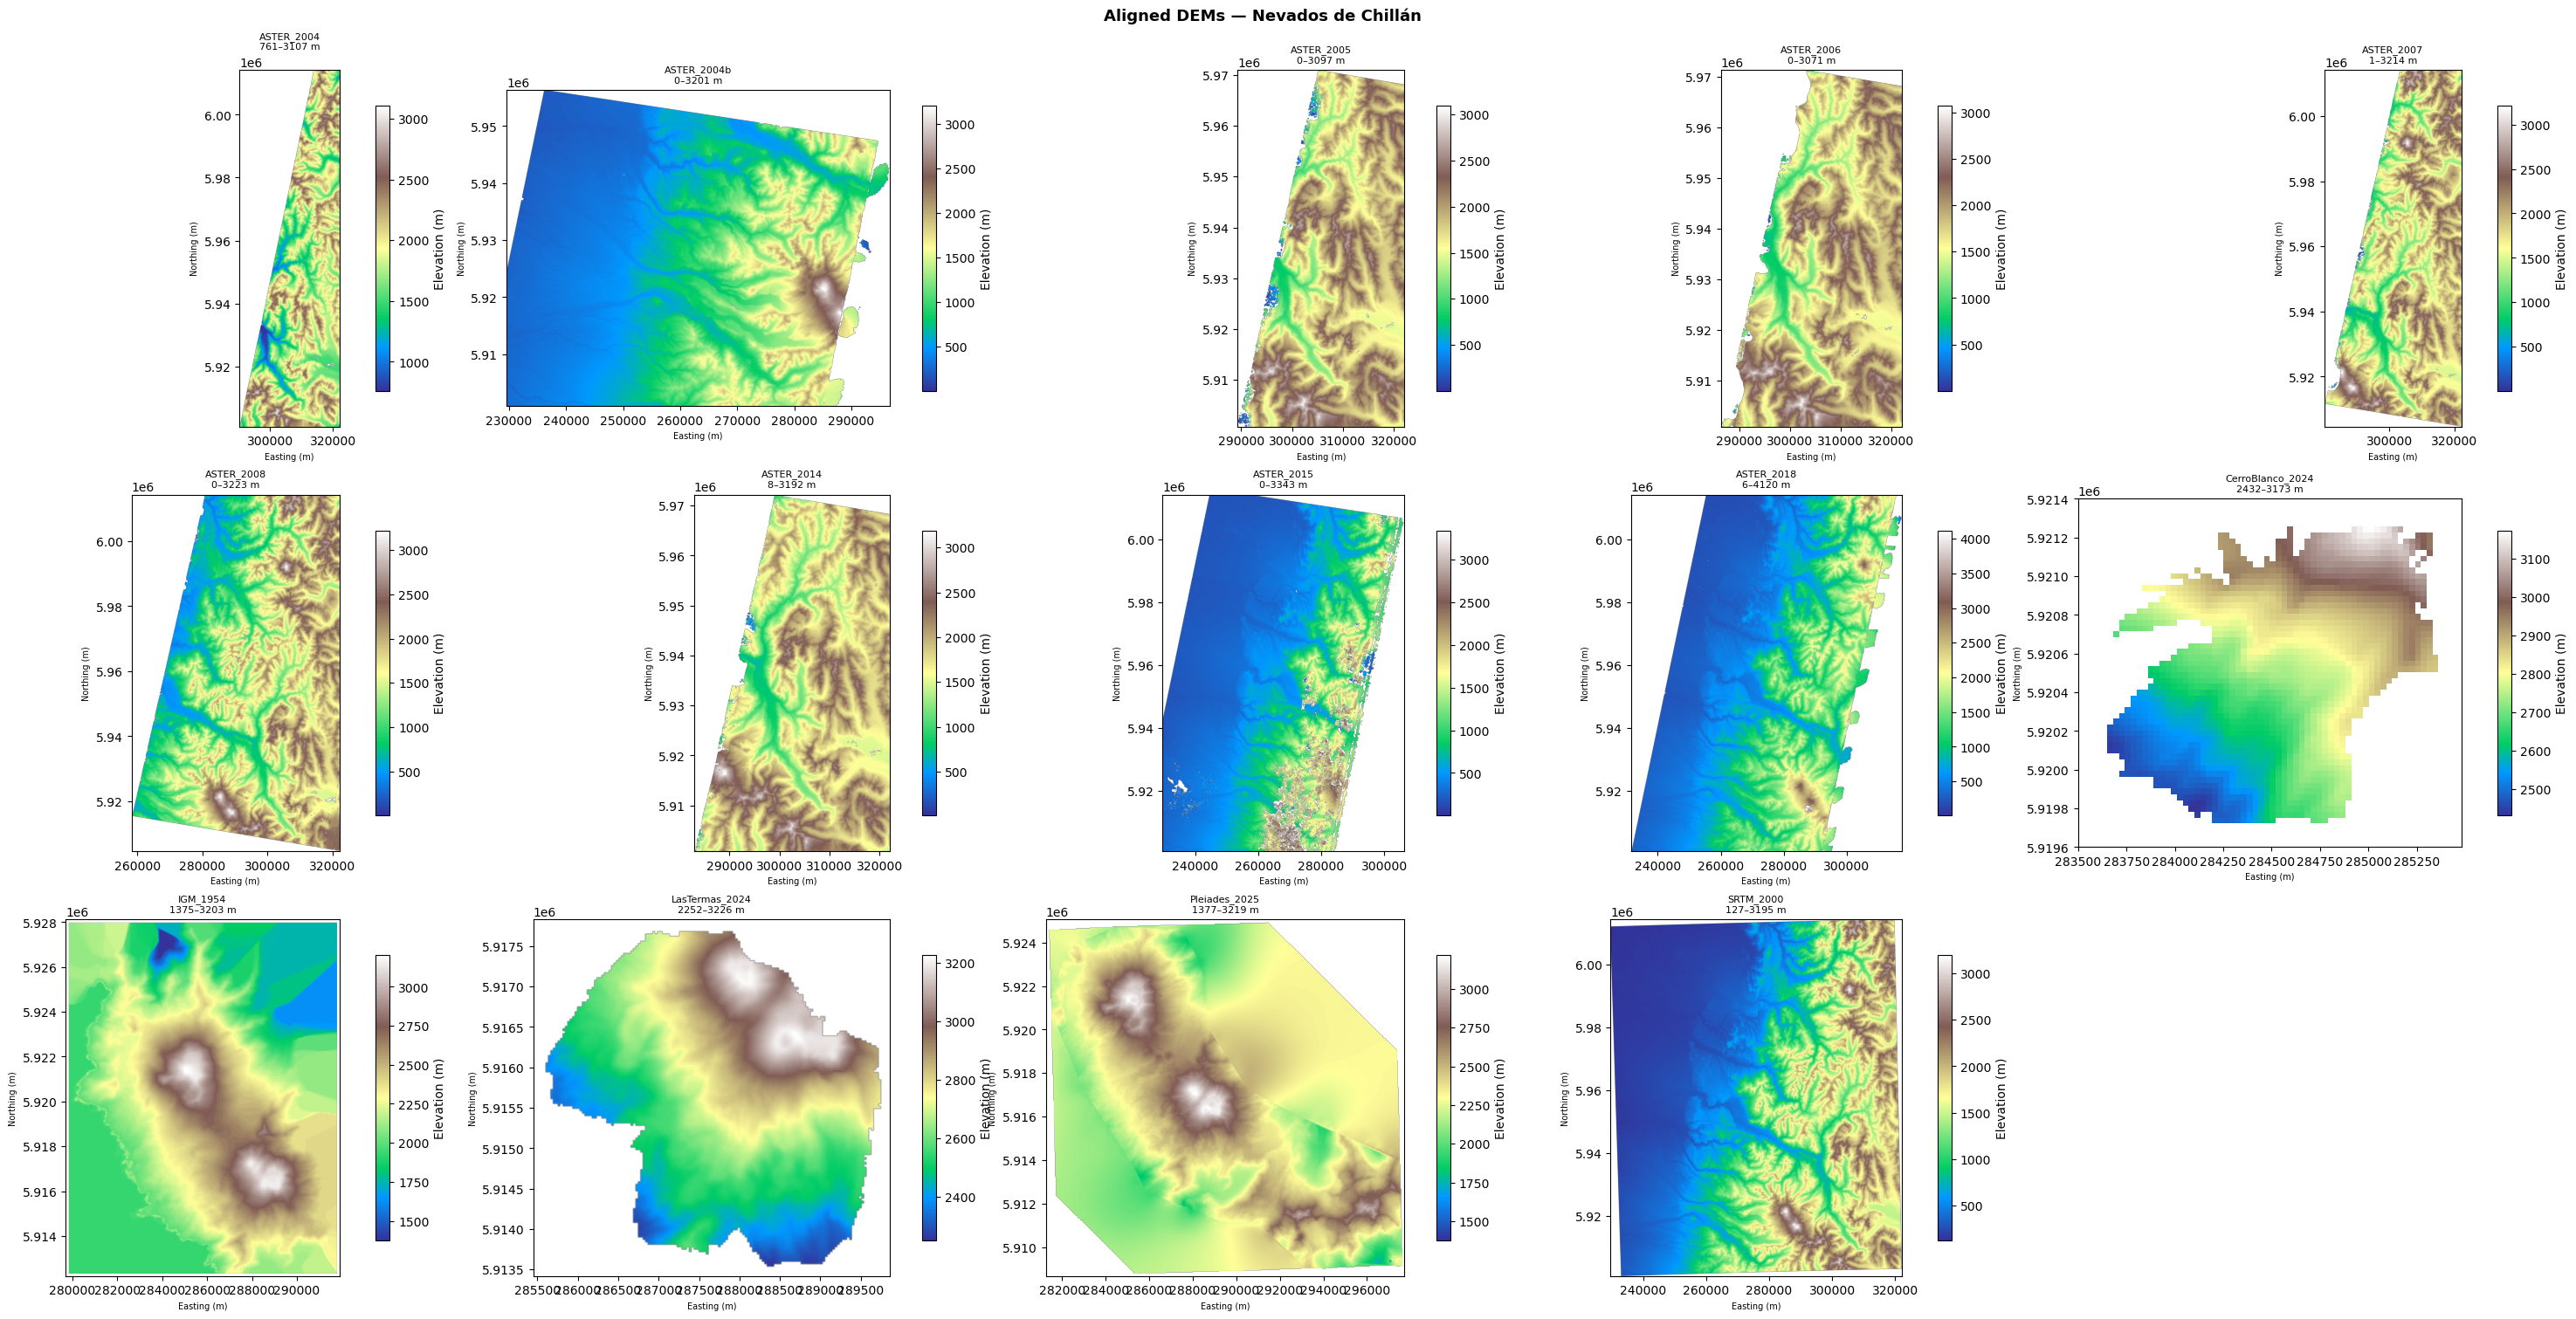

Saved: aligned_dems/aligned_dem_overview.png


In [23]:
# ==============================================================================
# Step 6: Visualization — all aligned DEMs
# ==============================================================================
print('\nGenerating overview plots...')

available = sorted([
    f.replace('_aligned.tif', '')
    for f in os.listdir(OUTPUT_FOLDER) if f.endswith('_aligned.tif')
])
print(f'Found {len(available)} aligned DEMs.')

ncols = 5
nrows = (len(available) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows),
                          constrained_layout=True)
axes = np.array(axes).flatten()

for i, dem_name in enumerate(available):
    ax   = axes[i]
    path = os.path.join(OUTPUT_FOLDER, f'{dem_name}_aligned.tif')
    with rasterio.open(path) as src:
        data = src.read(1).astype(float)
        if src.nodata is not None:
            data[data == src.nodata] = np.nan
        data[data > 1e10] = np.nan
        data[data < 0]    = np.nan
        b, t = src.bounds, src.transform
    valid_rows, valid_cols = np.where(np.isfinite(data))
    if len(valid_rows) == 0:
        ax.set_title(f'{dem_name}\n(no valid data)')
        ax.axis('off')
        continue
    r0 = max(valid_rows.min() - 5, 0);  r1 = min(valid_rows.max() + 5, data.shape[0])
    c0 = max(valid_cols.min() - 5, 0);  c1 = min(valid_cols.max() + 5, data.shape[1])
    extent = [b.left + c0*t.a, b.left + c1*t.a, b.top + r1*t.e, b.top + r0*t.e]
    im = ax.imshow(data[r0:r1, c0:c1], cmap='terrain', extent=extent, origin='upper')
    fig.colorbar(im, ax=ax, label='Elevation (m)', shrink=0.8)
    ax.set_title(f'{dem_name}\n{np.nanmin(data):.0f}–{np.nanmax(data):.0f} m', fontsize=8)
    ax.set_xlabel('Easting (m)', fontsize=7)
    ax.set_ylabel('Northing (m)', fontsize=7)

for j in range(len(available), len(axes)):
    axes[j].axis('off')

fig.suptitle('Aligned DEMs — Nevados de Chillán', fontsize=13, fontweight='bold')
fig.savefig(os.path.join(OUTPUT_FOLDER, 'aligned_dem_overview.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUTPUT_FOLDER}/aligned_dem_overview.png')

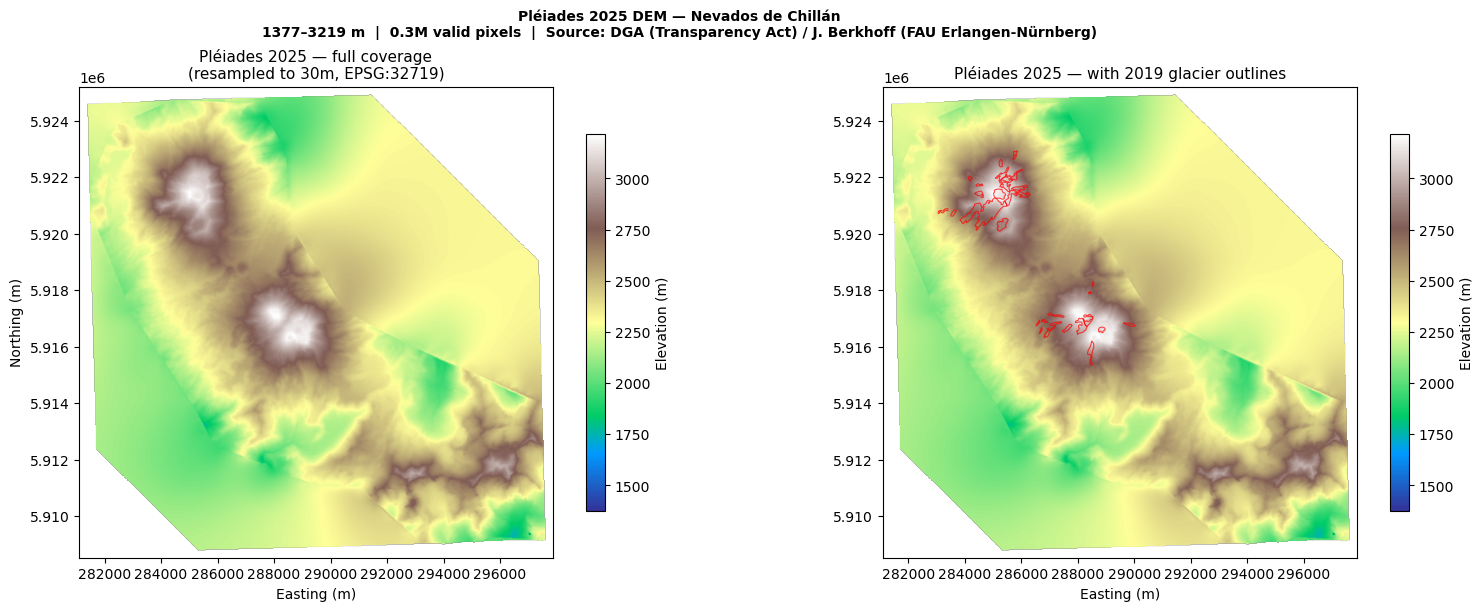

Saved: aligned_dems/Pleiades_2025_overview.png

Notebook 1 complete.
Aligned DEMs saved to: aligned_dems/
Pass aligned_dems/ folder to Notebook 2 for co-registration.


In [24]:
# ==============================================================================
# Step 7: Pléiades 2025 DEM — close-up visualization
# ==============================================================================
# The 2025 Pléiades DEM was obtained from the National Water Directorate (DGA)
# under the Chilean Transparency Act. It was built by Jorge Berkhoff
# (Institute of Geography, Friedrich-Alexander-Universität Erlangen-Nürnberg)
# from Pléiades stereo imagery (CNES, 0.5m native resolution, delivered at 1m).

pleiades_path = os.path.join(OUTPUT_FOLDER, 'Pleiades_2025_aligned.tif')

if os.path.exists(pleiades_path):
    with rasterio.open(pleiades_path) as src:
        data = src.read(1).astype(float)
        if src.nodata is not None:
            data[data == src.nodata] = np.nan
        data[data < 0]    = np.nan
        data[data > 7000] = np.nan
        b, t = src.bounds, src.transform

    valid_rows, valid_cols = np.where(np.isfinite(data))
    r0 = max(valid_rows.min() - 10, 0);  r1 = min(valid_rows.max() + 10, data.shape[0])
    c0 = max(valid_cols.min() - 10, 0);  c1 = min(valid_cols.max() + 10, data.shape[1])
    extent = [b.left + c0*t.a, b.left + c1*t.a, b.top + r1*t.e, b.top + r0*t.e]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

    # Full extent
    im0 = axes[0].imshow(data[r0:r1, c0:c1], cmap='terrain', extent=extent, origin='upper')
    fig.colorbar(im0, ax=axes[0], label='Elevation (m)', shrink=0.8)
    axes[0].set_title('Pléiades 2025 — full coverage\n(resampled to 30m, EPSG:32719)', fontsize=11)
    axes[0].set_xlabel('Easting (m)')
    axes[0].set_ylabel('Northing (m)')

    # Glacier outlines overlay
    gdf_2019 = gpd.read_file(GLACIER_2019_PATH).to_crs('EPSG:32719')
    im1 = axes[1].imshow(data[r0:r1, c0:c1], cmap='terrain', extent=extent, origin='upper')
    gdf_2019.plot(ax=axes[1], facecolor='none', edgecolor='red', linewidth=0.8, alpha=0.7)
    fig.colorbar(im1, ax=axes[1], label='Elevation (m)', shrink=0.8)
    axes[1].set_title('Pléiades 2025 — with 2019 glacier outlines', fontsize=11)
    axes[1].set_xlabel('Easting (m)')

    valid_px = np.sum(np.isfinite(data))
    fig.suptitle(f'Pléiades 2025 DEM — Nevados de Chillán\n'
                 f'{np.nanmin(data):.0f}–{np.nanmax(data):.0f} m  |  '
                 f'{valid_px/1e6:.1f}M valid pixels  |  '
                 f'Source: DGA (Transparency Act) / J. Berkhoff (FAU Erlangen-Nürnberg)',
                 fontsize=10, fontweight='bold')
    fig.savefig(os.path.join(OUTPUT_FOLDER, 'Pleiades_2025_overview.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {OUTPUT_FOLDER}/Pleiades_2025_overview.png')
else:
    print('Pleiades_2025_aligned.tif not found — run Steps 1-4 first.')

print('\nNotebook 1 complete.')
print(f'Aligned DEMs saved to: {OUTPUT_FOLDER}/')
print('Pass aligned_dems/ folder to Notebook 2 for co-registration.')